# Clustering: DBSCAN (Density-Based)

K-Means assumes clusters are roughly spherical blobs of similar size, and it forces *every* point into a cluster. **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) makes neither assumption:
- It finds clusters as **dense regions of points**, separated by sparse regions -- so it can discover **arbitrarily shaped** clusters (crescents, spirals, rings), not just blobs.
- Points that don't belong to any dense region are labeled **noise / outliers** (`-1`), rather than being force-fitted into the nearest cluster.
- You don't specify `k` up front -- the number of clusters is *discovered*, driven by two parameters: `eps` (neighborhood radius) and `min_samples` (minimum points to count as a dense region).

Part A demonstrates DBSCAN's core advantage on synthetic non-convex data, where K-Means visibly fails. Part B applies it to the real Mall Customers dataset and compares it against the K-Means results from the earlier notebook.

## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## Part A: Why Density-Based Clustering? A Synthetic Demo

Generate two interleaving crescent moons -- a shape that's trivially separable by eye, but **not** by distance-to-a-single-centroid, which is all K-Means can use.

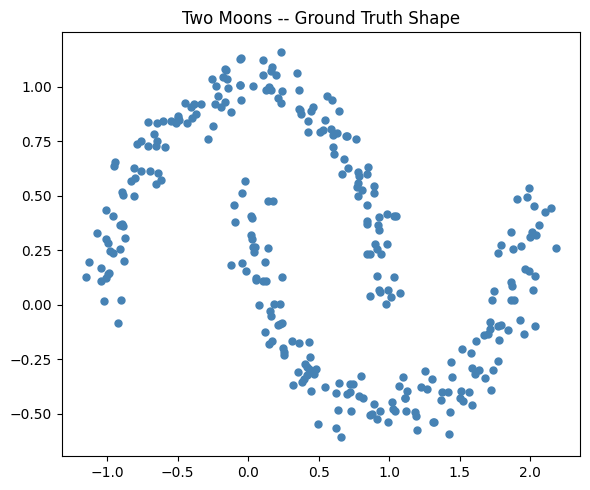

In [2]:
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.07, random_state=SEED)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_moons[:, 0], X_moons[:, 1], s=25, color="steelblue")
ax.set_title("Two Moons -- Ground Truth Shape")
plt.tight_layout()
plt.show()


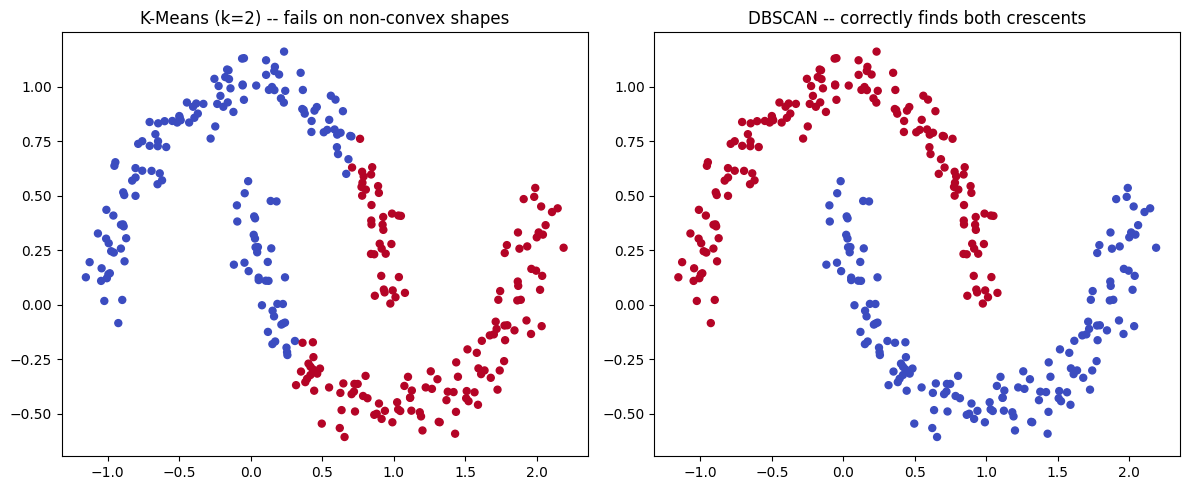

In [3]:
kmeans_moons = KMeans(n_clusters=2, random_state=SEED, n_init=10)
kmeans_labels = kmeans_moons.fit_predict(X_moons)

dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_labels, cmap="coolwarm", s=25)
axes[0].set_title("K-Means (k=2) -- fails on non-convex shapes")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_labels, cmap="coolwarm", s=25)
axes[1].set_title("DBSCAN -- correctly finds both crescents")

plt.tight_layout()
plt.show()


K-Means splits the moons with a straight-line boundary through the middle, because it can only reason about distance to 2 centroids -- it has no concept of "shape," only "nearness to a center point." DBSCAN instead grows clusters by following chains of nearby points through dense regions, so it correctly traces out each crescent regardless of its shape.

## Part B: Mall Customer Segmentation with DBSCAN

Same dataset as the K-Means notebook, so results are directly comparable.

In [4]:
DATA_URL = "https://raw.githubusercontent.com/lucko515/clustering-python/master/Customer%20in%20Mall%20clusterng/Mall_Customers.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "Mall_Customers.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

df = df_raw.drop_duplicates().reset_index(drop=True).drop(columns=["CustomerID"])
print("Shape:", df.shape)
df.head()


Loading data from local cache: data/Mall_Customers.csv
Shape: (200, 4)


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [5]:
cluster_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
X_proc = scaler.fit_transform(df[cluster_features])
print("Scaled. Shape:", X_proc.shape)


Scaled. Shape: (200, 3)


### Tuning `eps` and `min_samples`

`min_samples` is usually set as a rule of thumb around `2 * n_features` (here: 2 x 3 = 6) as a starting point -- larger values require denser regions to count as a cluster, which makes the model more robust to noise but stricter about what counts as a "real" cluster.

`eps` is trickier and usually tuned visually with a **k-distance plot**: for every point, compute the distance to its `k`-th nearest neighbor (`k = min_samples`), sort those distances, and plot them. The right `eps` is typically at the **knee** of this curve -- points below the knee are in dense regions (small k-th-neighbor distance), points above it are increasingly isolated.

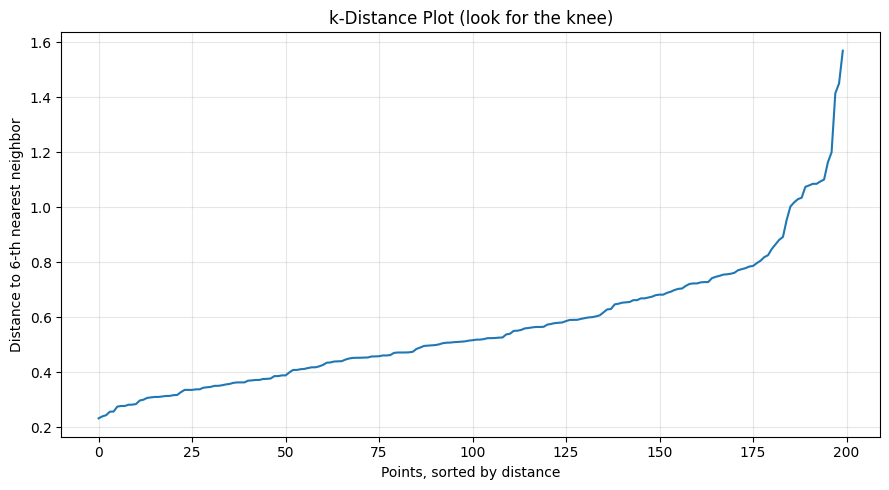

In [6]:
MIN_SAMPLES = 6

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X_proc)
distances, _ = neighbors.kneighbors(X_proc)

k_distances = np.sort(distances[:, -1])  # distance to the k-th nearest neighbor, sorted ascending

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_distances)
ax.set_xlabel("Points, sorted by distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
ax.set_title("k-Distance Plot (look for the knee)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
EPS = 0.6  # chosen from the knee of the k-distance plot above

dbscan_model = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan_model.fit_predict(X_proc)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points  : {n_noise} ({n_noise / len(dbscan_labels):.1%} of the data)")
print()
print(pd.Series(dbscan_labels).value_counts().sort_index().rename("count"))


Clusters found: 5
Noise points  : 34 (17.0% of the data)

-1     34
 0    105
 1      5
 2      4
 3     34
 4     18
Name: count, dtype: int64


### Evaluate & Compare to K-Means

Silhouette, Davies-Bouldin, and Calinski-Harabasz all require at least 2 clusters and no `-1`-only degenerate case -- so noise points are excluded from the score calculation (a standard convention for DBSCAN evaluation, since noise isn't a "cluster" being scored).

In [8]:
mask = dbscan_labels != -1  # exclude noise from clustering-quality metrics

db_silhouette = silhouette_score(X_proc[mask], dbscan_labels[mask])
db_davies_bouldin = davies_bouldin_score(X_proc[mask], dbscan_labels[mask])
db_calinski = calinski_harabasz_score(X_proc[mask], dbscan_labels[mask])

# Reference: K-Means with k=6 (the result from the earlier Mall Customers K-Means notebook)
kmeans_ref = KMeans(n_clusters=6, random_state=SEED, n_init=10)
kmeans_ref_labels = kmeans_ref.fit_predict(X_proc)

km_silhouette = silhouette_score(X_proc, kmeans_ref_labels)
km_davies_bouldin = davies_bouldin_score(X_proc, kmeans_ref_labels)
km_calinski = calinski_harabasz_score(X_proc, kmeans_ref_labels)

comparison = pd.DataFrame({
    "DBSCAN (noise excluded)": [db_silhouette, db_davies_bouldin, db_calinski, n_clusters, n_noise],
    "K-Means (k=6)": [km_silhouette, km_davies_bouldin, km_calinski, 6, 0],
}, index=["Silhouette (higher better)", "Davies-Bouldin (lower better)", "Calinski-Harabasz (higher better)", "n_clusters", "n_noise_points"])

comparison.round(3)


,DBSCAN (noise excluded),K-Means (k=6)
Silhouette (higher better),0.194,0.428
Davies-Bouldin (lower better),1.115,0.825
Calinski-Harabasz (higher better),31.139,135.102
n_clusters,5.000,6.000
n_noise_points,34.000,0.000


On this particular dataset, the customer segments are fairly smooth, roughly convex blobs (not crescents or rings), so K-Means' spherical-cluster assumption is actually a reasonable fit here -- DBSCAN's main edge (arbitrary shapes) doesn't get to shine the way it did on the two-moons example. DBSCAN's real value-add here is different: it explicitly flags outlier customers that don't fit neatly into any dense group, rather than force-fitting them into the nearest centroid the way K-Means always does.

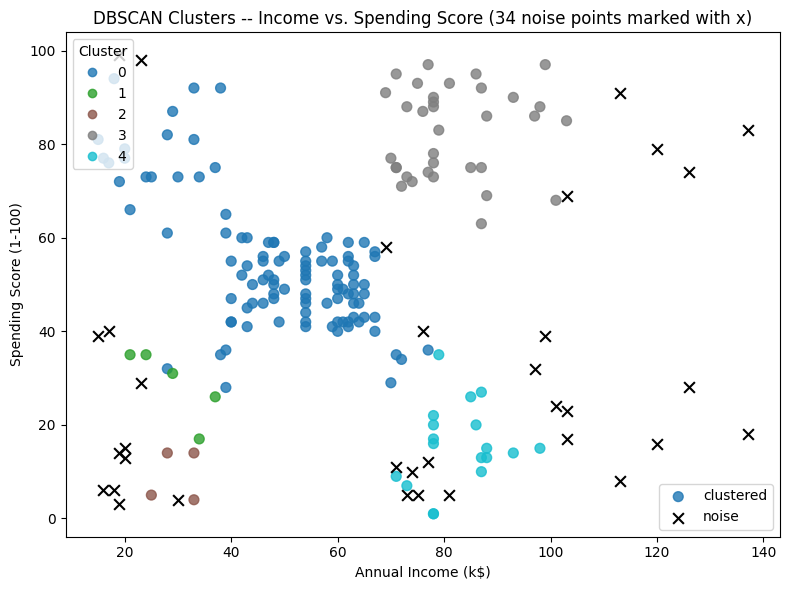

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

is_noise = dbscan_labels == -1
scatter = ax.scatter(
    df.loc[~is_noise, "Annual Income (k$)"], df.loc[~is_noise, "Spending Score (1-100)"],
    c=dbscan_labels[~is_noise], cmap="tab10", s=50, alpha=0.8, label="clustered",
)
ax.scatter(
    df.loc[is_noise, "Annual Income (k$)"], df.loc[is_noise, "Spending Score (1-100)"],
    c="black", marker="x", s=60, label="noise",
)
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.set_title(f"DBSCAN Clusters -- Income vs. Spending Score ({n_noise} noise points marked with x)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper left")
ax.add_artist(legend1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [10]:
df["dbscan_cluster"] = dbscan_labels
print("Customers flagged as noise/outliers by DBSCAN:")
df[df["dbscan_cluster"] == -1][cluster_features + ["Genre"]]


Customers flagged as noise/outliers by DBSCAN:


,Age,Annual Income (k$),Spending Score (1-100),Genre
0,19,15,39,Male
2,20,16,6,Female
4,31,17,40,Female
6,35,18,6,Female
8,64,19,3,Male
10,67,19,14,Male
11,35,19,99,Female
12,58,20,15,Female
14,37,20,13,Male
18,52,23,29,Male


## Inference on New Points

DBSCAN has no built-in `.predict()` for genuinely new points (it's a fundamentally *transductive* algorithm -- cluster membership is defined only in terms of the training set's density structure, not a reusable model). The common workaround: find the new point's nearest neighbor(s) among the already-clustered points, and assign it that neighbor's cluster **only if** it falls within `eps` of a core point -- otherwise it's noise, same as any other point that doesn't fall in a dense region.

In [11]:
def assign_dbscan_cluster(age, annual_income_k, spending_score, dbscan_model, scaler, X_train_scaled, train_labels, eps):
    input_df = pd.DataFrame([{
        "Age": age,
        "Annual Income (k$)": annual_income_k,
        "Spending Score (1-100)": spending_score,
    }])
    input_scaled = scaler.transform(input_df)

    dists = np.linalg.norm(X_train_scaled - input_scaled, axis=1)
    nearest_idx = np.argmin(dists)
    nearest_dist = dists[nearest_idx]

    if nearest_dist <= eps and train_labels[nearest_idx] != -1:
        return train_labels[nearest_idx]
    return -1  # too far from any dense region -> noise


cluster = assign_dbscan_cluster(27, 85, 90, dbscan_model, scaler, X_proc, dbscan_labels, EPS)
print(f"Assigned cluster: {cluster}")


Assigned cluster: 3


## Save the Model (optional)

In [12]:
joblib.dump({
    "model": dbscan_model, "scaler": scaler, "features": cluster_features,
    "X_train_scaled": X_proc, "train_labels": dbscan_labels, "eps": EPS,
}, "mall_dbscan.joblib")
print("Model + supporting data saved to mall_dbscan.joblib")


Model + supporting data saved to mall_dbscan.joblib
